In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

import timm                          # for ViT pretrained weights
import pandas as pd
import numpy as np
import pickle, json, time, math
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt


In [2]:
import os
base = '/kaggle/input/datasets/joox1113/interior-room-images-captions-houzz'
print(os.listdir(base + '/images'))
print(os.listdir(base + '/images/images'))


['images']
['bathroom', 'pool', 'bedroom', 'kitchen', 'home-office', 'living-room']


In [3]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
PREP   = Path('/kaggle/input/datasets/joox1113/interior-room-images-captions-houzz/for data kaggle/for data kaggle/stage3_preprocessing/preprocessing_outputs')

# ── load vocabulary ──
with open(PREP / 'vocab.pkl', 'rb') as f:
    vocab = pickle.load(f)

word2idx   = vocab['word2idx']    # word → integer index
idx2word   = vocab['idx2word']    # integer index → word
VOCAB_SIZE = vocab['vocab_size']  # 4207
PAD_IDX    = vocab['pad_idx']     # 0
START_IDX  = vocab['start_idx']   # 1
END_IDX    = vocab['end_idx']     # 2

with open(PREP / 'preprocessing_config.json') as f:
    cfg = json.load(f)

# ── load splits ──
train_df = pd.read_csv(PREP / 'split_train.csv')
val_df   = pd.read_csv(PREP / 'split_val.csv')
test_df  = pd.read_csv(PREP / 'split_test.csv')

# tokens were saved as strings in CSV → eval() converts them back to Python lists
train_df['tokens'] = train_df['tokens'].apply(eval)
val_df['tokens']   = val_df['tokens'].apply(eval)
test_df['tokens']  = test_df['tokens'].apply(eval)

print('device     :', DEVICE)
print('vocab size :', VOCAB_SIZE)
print('train      :', len(train_df))
print('val        :', len(val_df))
print('test       :', len(test_df))


device     : cuda
vocab size : 4207
train      : 10984
val        : 1373
test       : 1374


In [4]:
# ── Hyperparameters ──

EMBED_DIM        = 256   # d_model for both encoder projection and transformer decoder
NHEAD            = 8    # number of attention heads (256 / 8 = 32 per head)
NUM_DEC_LAYERS   = 4    # number of TransformerDecoder layers stacked
DIM_FF           = 1024  # feedforward hidden dim inside each decoder layer
DROPOUT          = 0.1  # dropout rate on embeddings + decoder layers

BATCH_SIZE       = 32   # images per gradient update
LR               = 3e-4  # Adam learning rate
NUM_EPOCHS       = 50   # max epochs — early stopping will kick in earlier
PATIENCE         = 5    # stop if val_loss doesn't improve for 5 consecutive epochs
MAX_CAPTION_LEN  = cfg['MAX_CAPTION_LEN']  # 40 — same as Model 1 & 2

IMAGES_BASE = Path('/kaggle/input/datasets/joox1113/interior-room-images-captions-houzz/images/images')


In [5]:
class HouzzDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df        = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)        # how many items in the dataset

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img_name = '/'.join(row['local_path'].split('/')[1:])   # strip leading 'images/'
        image    = Image.open(IMAGES_BASE / img_name).convert('RGB')
        if self.transform:
            image = self.transform(image)                       # resize + normalize
        caption = torch.tensor(row['tokens'], dtype=torch.long)
        return image, caption                                   # (3,224,224) tensor, (40,) tensor


In [6]:
transform = transforms.Compose([
    transforms.Resize(tuple(cfg['IMG_SIZE'])),                        # → 224×224
    transforms.ToTensor(),                                            # pixel [0,255] → tensor [0,1]
    transforms.Normalize(mean=cfg['IMG_MEAN'], std=cfg['IMG_STD']),   # ImageNet stats
])

train_ds = HouzzDataset(train_df, transform)
val_ds   = HouzzDataset(val_df,   transform)
test_ds  = HouzzDataset(test_df,  transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=1,          shuffle=False, num_workers=2)

print('train batches :', len(train_loader))
print('val batches   :', len(val_loader))
print('test samples  :', len(test_ds))


train batches : 344
val batches   : 43
test samples  : 1374


In [7]:
# ── Encoder : ViT-Base/16 pretrained on ImageNet21k, ALL weights FROZEN ──
#
# Key difference from Model 1 & 2 (ResNet50):
#   - ViT splits the 224×224 image into 14×14 = 196 non-overlapping 16×16 patches
#   - Each patch is linearly projected to 768-dim, then processed by 12 Transformer blocks
#   - Output: (B, 197, 768) — 196 patch tokens + 1 CLS token
#   - We DROP the CLS token and keep the 196 spatial patch tokens
#   - These 196 tokens are the 'memory' for the Transformer decoder cross-attention
#   - A learnable Linear(768 → 256) projects to our d_model
#
# Why frozen?  Same reason as Model 1: frozen encoder won the ablation study
# (CIDEr 0.89 vs 0.73). ImageNet inductive bias generalises better than
# task-specific fine-tuning on ~11K samples.

class ViTEncoder(nn.Module):
    def __init__(self, embed_dim):
        super().__init__()
        # global_pool='' → return ALL tokens (B, 197, 768) instead of just CLS
        self.backbone = timm.create_model(
            'vit_base_patch16_224',
            pretrained   = True,
            num_classes  = 0,       # remove classification head
            global_pool  = ''       # return full token sequence (B, 197, 768)
        )
        for p in self.backbone.parameters():
            p.requires_grad = False  # FREEZE all ViT weights

        self.proj = nn.Linear(768, embed_dim)   # 768 → 256, this layer DOES train

    def forward(self, images):
        with torch.no_grad():             # no gradient through ViT backbone
            x = self.backbone(images)     # (B, 197, 768)
        x = x[:, 1:, :]                  # drop CLS token → (B, 196, 768)
        return self.proj(x)               # (B, 196, embed_dim)


In [8]:
def make_causal_mask(sz, device):
    """
    Upper-triangular boolean mask of shape (sz, sz).
    True  = this position is IGNORED (future token — cannot attend to it).
    False = this position is VISIBLE.

    Example for sz=4:
        [[F, T, T, T],
         [F, F, T, T],
         [F, F, F, T],
         [F, F, F, F]]

    This prevents the decoder from peeking at future tokens during training.
    """
    return torch.triu(torch.ones(sz, sz, device=device), diagonal=1).bool()


In [9]:
# ── Decoder : Transformer Decoder with cross-attention over ViT patch tokens ──
#
# Architecture per layer:
#   1. Masked Multi-Head Self-Attention  → word attends only to PAST words (causal)
#   2. Multi-Head Cross-Attention        → word attends to ALL 196 image patch tokens
#   3. Feed-Forward Network (Linear → ReLU → Linear)
#   4. LayerNorm + residual after each sub-layer
#
# Input  : token sequence (B, T)  where T = MAX_CAPTION_LEN - 1
# Output : logit scores   (B, T, vocab_size)
#
# Positional encoding: LEARNED embeddings (nn.Embedding) — simpler than sinusoidal,
# works well for fixed max-length sequences.

class TransformerDecoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, nhead, num_layers, dim_ff, dropout, max_len):
        super().__init__()
        self.embed     = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)  # token → vector
        self.pos_embed = nn.Embedding(max_len,    embed_dim)                        # position → vector
        self.dropout   = nn.Dropout(dropout)

        decoder_layer = nn.TransformerDecoderLayer(
            d_model        = embed_dim,
            nhead          = nhead,
            dim_feedforward= dim_ff,
            dropout        = dropout,
            batch_first    = True     # (B, T, d_model) convention — easier to read
        )
        self.transformer = nn.TransformerDecoder(decoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(embed_dim, vocab_size)   # hidden → vocab scores

    def forward(self, captions, memory, tgt_mask=None, tgt_key_padding_mask=None):
        """
        captions : (B, T)              — token ids, input to the decoder
        memory   : (B, S, embed_dim)  — encoder output (196 ViT patch tokens)
        tgt_mask : (T, T) bool        — causal mask (future = True = blocked)
        tgt_key_padding_mask : (B, T) bool — True where caption token is PAD
        """
        B, T = captions.shape
        positions = torch.arange(T, device=captions.device).unsqueeze(0).expand(B, -1)  # (B, T)

        # word embedding + positional embedding, then dropout
        x = self.dropout(self.embed(captions) + self.pos_embed(positions))  # (B, T, embed_dim)

        # run through all decoder layers
        out = self.transformer(
            x, memory,
            tgt_mask             = tgt_mask,
            tgt_key_padding_mask = tgt_key_padding_mask
        )  # (B, T, embed_dim)

        return self.fc(out)   # (B, T, vocab_size)


In [10]:
class CaptionModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, nhead, num_layers, dim_ff, dropout, max_len):
        super().__init__()
        self.encoder = ViTEncoder(embed_dim)
        self.decoder = TransformerDecoder(
            vocab_size, embed_dim, nhead, num_layers, dim_ff, dropout, max_len
        )

    def forward(self, images, captions):
        """
        Training forward pass (teacher forcing).
        images   : (B, 3, 224, 224)
        captions : (B, MAX_LEN)   — full token sequence including START and END

        Input  to decoder: captions[:, :-1]  → [START, w1, w2, ..., wN, PAD, ...]
        Target for loss  : captions[:, 1:]   → [w1, w2, ..., wN, END, PAD, ...]

        This shift-by-one is standard seq2seq: given token t, predict token t+1.
        """
        memory = self.encoder(images)           # (B, 196, embed_dim)

        tgt = captions[:, :-1]                  # (B, MAX_LEN-1) — decoder input
        T   = tgt.shape[1]

        tgt_mask             = make_causal_mask(T, images.device)  # (T, T)
        tgt_key_padding_mask = (tgt == PAD_IDX)                    # (B, T), True where PAD

        logits = self.decoder(tgt, memory, tgt_mask, tgt_key_padding_mask)  # (B, T, vocab_size)
        return logits

    @torch.no_grad()
    def generate(self, image, max_len=40):
        """
        Autoregressive greedy decoding for inference.
        Transformer has no internal state → feed the FULL token sequence so far at each step.
        """
        self.eval()
        memory = self.encoder(image.unsqueeze(0))   # (1, 196, embed_dim)
        tokens = [START_IDX]                         # start with <START> token

        for _ in range(max_len):
            tgt      = torch.tensor([tokens], device=image.device)    # (1, t)
            T        = tgt.shape[1]
            tgt_mask = make_causal_mask(T, image.device)              # (t, t)

            logits     = self.decoder(tgt, memory, tgt_mask)          # (1, t, vocab_size)
            next_token = logits[0, -1, :].argmax().item()             # pick best word at last position

            if next_token == END_IDX:
                break                                                  # stop at <END>
            tokens.append(next_token)

        # decode token ids → words, skip special tokens
        words = [idx2word[t] for t in tokens[1:] if t not in (PAD_IDX, START_IDX, END_IDX)]
        return ' '.join(words)


In [11]:
model = CaptionModel(
    vocab_size  = VOCAB_SIZE,
    embed_dim   = EMBED_DIM,
    nhead       = NHEAD,
    num_layers  = NUM_DEC_LAYERS,
    dim_ff      = DIM_FF,
    dropout     = DROPOUT,
    max_len     = MAX_CAPTION_LEN
).to(DEVICE)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'trainable params : {trainable:,}')   # decoder + proj layer only
print(f'total params     : {total:,}')        # includes frozen ViT

criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)  # ignore PAD tokens in loss
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()), lr=LR
)


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

trainable params : 6,579,055
total params     : 92,377,711


In [12]:
# ── Smoke test : make sure shapes are correct before wasting GPU time ──
B = 2
dummy_imgs = torch.randn(B, 3, 224, 224).to(DEVICE)
dummy_caps = torch.randint(0, VOCAB_SIZE, (B, MAX_CAPTION_LEN)).to(DEVICE)

logits  = model(dummy_imgs, dummy_caps)
targets = dummy_caps[:, 1:]   # shifted target
print('input image shape   :', dummy_imgs.shape)              # (2, 3, 224, 224)
print('input caption shape :', dummy_caps.shape)              # (2, 40)
print('output logits shape :', logits.shape)                  # (2, 39, 4207)
print('target shape        :', targets.shape)                 # (2, 39)

loss = criterion(logits.reshape(-1, VOCAB_SIZE), targets.reshape(-1))
print('test loss           :', loss.item())


input image shape   : torch.Size([2, 3, 224, 224])
input caption shape : torch.Size([2, 40])
output logits shape : torch.Size([2, 39, 4207])
target shape        : torch.Size([2, 39])
test loss           : 8.563264846801758


In [13]:
SAVE = Path('model_outputs')
SAVE.mkdir(exist_ok=True)

history         = {'train_loss': [], 'val_loss': []}
best_val        = float('inf')
patience_counter = 0

for epoch in range(NUM_EPOCHS):
    t0 = time.time()

    # ── TRAIN ──
    model.train()
    total_train = 0
    for images, captions in train_loader:
        images, captions = images.to(DEVICE), captions.to(DEVICE)

        logits  = model(images, captions)             # (B, MAX_LEN-1, vocab_size)
        targets = captions[:, 1:]                      # (B, MAX_LEN-1)  shift by 1
        loss    = criterion(logits.reshape(-1, VOCAB_SIZE), targets.reshape(-1))

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # gradient clipping — helps Transformer stability
        optimizer.step()
        total_train += loss.item()

    # ── VALIDATE ──
    model.eval()
    total_val = 0
    with torch.no_grad():
        for images, captions in val_loader:
            images, captions = images.to(DEVICE), captions.to(DEVICE)
            logits   = model(images, captions)
            targets  = captions[:, 1:]
            loss     = criterion(logits.reshape(-1, VOCAB_SIZE), targets.reshape(-1))
            total_val += loss.item()

    train_loss = total_train / len(train_loader)
    val_loss   = total_val   / len(val_loader)
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)

    # ── EARLY STOPPING ──
    flag = ''
    if val_loss < best_val:
        best_val         = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), SAVE / 'model3_vit_transformer_best.pt')
        flag = ' ← saved'
    else:
        patience_counter += 1

    print(f'epoch {epoch+1:>2}/{NUM_EPOCHS}  '
          f'train={train_loss:.4f}  val={val_loss:.4f}  '
          f'({time.time()-t0:.0f}s){flag}')

    if patience_counter >= PATIENCE:
        print(f'\n⏹  early stopping — val loss did not improve for {PATIENCE} epochs')
        break

print(f'\nbest val loss: {best_val:.4f}')

with open(SAVE / 'model3_vit_transformer_history.json', 'w') as f:
    json.dump(history, f, indent=2)


epoch  1/50  train=4.1292  val=3.1178  (142s) ← saved
epoch  2/50  train=3.0963  val=2.8777  (156s) ← saved
epoch  3/50  train=2.8647  val=2.7580  (159s) ← saved
epoch  4/50  train=2.7025  val=2.6972  (160s) ← saved
epoch  5/50  train=2.5601  val=2.6639  (160s) ← saved
epoch  6/50  train=2.4258  val=2.6443  (162s) ← saved
epoch  7/50  train=2.2966  val=2.6338  (160s) ← saved
epoch  8/50  train=2.1719  val=2.6432  (159s)
epoch  9/50  train=2.0527  val=2.6661  (159s)
epoch 10/50  train=1.9238  val=2.6952  (159s)
epoch 11/50  train=1.8012  val=2.7323  (159s)
epoch 12/50  train=1.6853  val=2.7917  (159s)

⏹  early stopping — val loss did not improve for 5 epochs

best val loss: 2.6338


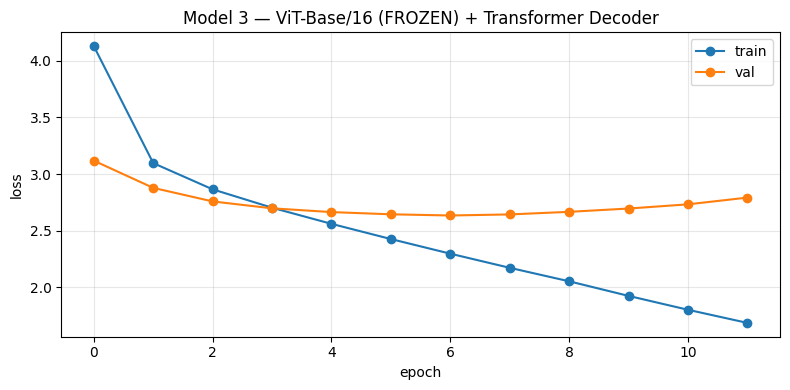

In [14]:
plt.figure(figsize=(8, 4))
plt.plot(history['train_loss'], label='train', marker='o')
plt.plot(history['val_loss'],   label='val',   marker='o')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('Model 3 — ViT-Base/16 (FROZEN) + Transformer Decoder')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [15]:
# ── Load best checkpoint + generate captions for the full test set ──
model.load_state_dict(torch.load(SAVE / 'model3_vit_transformer_best.pt', map_location=DEVICE))
model.eval()

predictions = []
for images, captions in test_loader:
    image  = images[0].to(DEVICE)    # batch_size=1 so just grab the single image
    pred   = model.generate(image, max_len=MAX_CAPTION_LEN)
    predictions.append(pred)

print(f'generated {len(predictions)} captions')
print('\nSample predictions:')
for i in range(5):
    true_cap = test_df.iloc[i]['caption'] if 'caption' in test_df.columns else test_df.iloc[i]['description']
    print(f'  [{i}] TRUE : {true_cap[:80]}')
    print(f'       PRED : {predictions[i]}')
    print()


generated 1374 captions

Sample predictions:
  [0] TRUE : freestanding desk brown floor and light wood floor home office with white walls
       PRED : freestanding desk medium tone wood floor and brown floor study room with gray walls

  [1] TRUE : island style formal and enclosed dark wood floor living room with beige walls a 
       PRED : country open concept dark wood floor and brown floor living room with beige walls a standard fireplace a brick fireplace and no tv

  [2] TRUE : craft room with lighted countertop built in desk light wood floor craft room pho
       PRED : craft room built in desk dark wood floor craft room idea with gray walls

  [3] TRUE : freestanding desk study room with brown walls
       PRED : freestanding desk dark wood floor and brown floor study room with gray walls

  [4] TRUE : a l shaped medium tone wood floor kitchen with a sink shaker cabinets white cabi
       PRED : l shaped medium tone wood floor and brown floor kitchen with an undermount sink fl

In [16]:
# ── Metrics : BLEU-1, BLEU-4, METEOR, ROUGE-L, CIDEr ──
# same evaluation code as Model 1 for fair comparison

from nltk.translate.bleu_score  import corpus_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score as nltk_meteor
from rouge_score                import rouge_scorer
import nltk
nltk.download('wordnet', quiet=True)
nltk.download('punkt',   quiet=True)

# grab ground-truth captions
gt_col = 'caption' if 'caption' in test_df.columns else 'description'
references_raw = test_df[gt_col].tolist()

# tokenize references
refs_tok  = [r.lower().split() for r in references_raw]
hyps_tok  = [p.lower().split() for p in predictions]

# BLEU
smooth = SmoothingFunction().method1
bleu1  = corpus_bleu([[r] for r in refs_tok], hyps_tok, weights=(1,0,0,0),        smoothing_function=smooth)
bleu4  = corpus_bleu([[r] for r in refs_tok], hyps_tok, weights=(0.25,0.25,0.25,0.25), smoothing_function=smooth)

# METEOR
meteor = np.mean([nltk_meteor([r], h) for r, h in zip(refs_tok, hyps_tok)])

# ROUGE-L
scorer  = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
rouge_l = np.mean([scorer.score(r, h)['rougeL'].fmeasure for r, h in zip(references_raw, predictions)])

# CIDEr (optional — requires pycocoevalcap)
try:
    from pycocoevalcap.cider.cider import Cider
    cider_scorer = Cider()
    gts = {i: [references_raw[i]] for i in range(len(references_raw))}
    res = {i: [predictions[i]]    for i in range(len(predictions))}
    cider, _ = cider_scorer.compute_score(gts, res)
except ImportError:
    cider = None
    print('pycocoevalcap not found — CIDEr skipped')

print(f'BLEU-1  : {bleu1:.4f}')
print(f'BLEU-4  : {bleu4:.4f}')
print(f'METEOR  : {meteor:.4f}')
print(f'ROUGE-L : {rouge_l:.4f}')
if cider is not None:
    print(f'CIDEr   : {cider:.4f}')


pycocoevalcap not found — CIDEr skipped
BLEU-1  : 0.3638
BLEU-4  : 0.1830
METEOR  : 0.3658
ROUGE-L : 0.3660


In [17]:
# ── Per-room accuracy : does the generated caption contain a room-relevant keyword? ──
# same logic as Model 1 for fair comparison

room_keywords = {
    'bathroom':    ['bathroom', 'bath', 'shower', 'toilet', 'vanity'],
    'bedroom':     ['bedroom', 'bed', 'master'],
    'home-office': ['office', 'desk', 'study'],
    'kitchen':     ['kitchen', 'pantry'],
    'living-room': ['living', 'lounge'],
    'pool':        ['pool', 'hot tub', 'spa'],
}

correct_per_room = {r: {'correct': 0, 'total': 0} for r in room_keywords}

for idx in range(len(test_df)):
    room      = test_df.iloc[idx]['room_type']
    generated = predictions[idx].lower()
    correct_per_room[room]['total'] += 1
    if any(kw in generated for kw in room_keywords[room]):
        correct_per_room[room]['correct'] += 1

print('Per-room accuracy:')
total_correct = 0
for room, v in correct_per_room.items():
    acc = v['correct'] / v['total'] * 100 if v['total'] > 0 else 0
    total_correct += v['correct']
    print(f'  {room:<15} {acc:.1f}%  ({v["correct"]}/{v["total"]})')

print(f'\nOverall Accuracy : {total_correct / len(test_df) * 100:.1f}%')


Per-room accuracy:
  bathroom        95.4%  (250/262)
  bedroom         80.7%  (176/218)
  home-office     67.7%  (149/220)
  kitchen         89.3%  (218/244)
  living-room     74.8%  (196/262)
  pool            87.5%  (147/168)

Overall Accuracy : 82.7%


In [18]:
import subprocess
subprocess.run(['pip', 'install', 'pycocoevalcap', '--quiet'], check=True)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.3/104.3 MB 17.7 MB/s eta 0:00:00


CompletedProcess(args=['pip', 'install', 'pycocoevalcap', '--quiet'], returncode=0)

In [19]:
# ── Save metrics + predictions ──
metrics = {
    'model'         : 'Model 3 — ViT-Base/16 (FROZEN) + Transformer Decoder',
    'best_val_loss' : round(best_val, 4),
    'test_samples'  : len(predictions),
    'BLEU-1'        : round(bleu1,   4),
    'BLEU-4'        : round(bleu4,   4),
    'METEOR'        : round(meteor,  4),
    'ROUGE-L'       : round(rouge_l, 4),
    'CIDEr'         : round(cider,   4) if cider is not None else None,
}

with open(SAVE / 'model3_vit_transformer_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

# save predictions side-by-side with ground-truth for report / error analysis
results = test_df[['local_path', 'room_type']].copy()
results['true_caption'] = references_raw
results['generated']    = predictions
results.to_csv(SAVE / 'model3_vit_transformer_predictions.csv', index=False)

print(json.dumps(metrics, indent=2))


{
  "model": "Model 3 \u2014 ViT-Base/16 (FROZEN) + Transformer Decoder",
  "best_val_loss": 2.6338,
  "test_samples": 1374,
  "BLEU-1": 0.3638,
  "BLEU-4": 0.183,
  "METEOR": 0.3658,
  "ROUGE-L": 0.366,
  "CIDEr": null
}


In [20]:
# ── 3-model comparison table (fill after all models are run) ──

comparison = {
    'Metric'   : ['Best Val Loss', 'BLEU-1', 'BLEU-4', 'METEOR', 'ROUGE-L', 'CIDEr', 'Room Acc'],
    'Model 1\nResNet50 + LSTM'            : [2.4743, 0.3592, 0.1634, 0.3570, 0.3713, 0.8897, '79.9%'],
    'Model 3\nViT + Transformer'          : [
        round(best_val, 4),
        round(bleu1,    4),
        round(bleu4,    4),
        round(meteor,   4),
        round(rouge_l,  4),
        round(cider,    4) if cider else '?',
        f'{total_correct / len(test_df) * 100:.1f}%'
    ]
}

df_compare = pd.DataFrame(comparison).set_index('Metric')
print(df_compare.to_string())


              Model 1\nResNet50 + LSTM Model 3\nViT + Transformer
Metric                                                           
Best Val Loss                   2.4743                     2.6338
BLEU-1                          0.3592                     0.3638
BLEU-4                          0.1634                      0.183
METEOR                           0.357                     0.3658
ROUGE-L                         0.3713                      0.366
CIDEr                           0.8897                          ?
Room Acc                         79.9%                      82.7%


/tmp/ipykernel_23/2033699337.py:32: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_23/2033699337.py:32: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_23/2033699337.py:33: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(SAVE / 'model3_sample_predictions.png', bbox_inches='tight', dpi=150)
/tmp/ipykernel_23/2033699337.py:33: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  plt.savefig(SAVE / 'model3_sample_predictions.png', bbox_inches='tight', dpi=150)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129302 (\N{ROBOT FACE}) mi

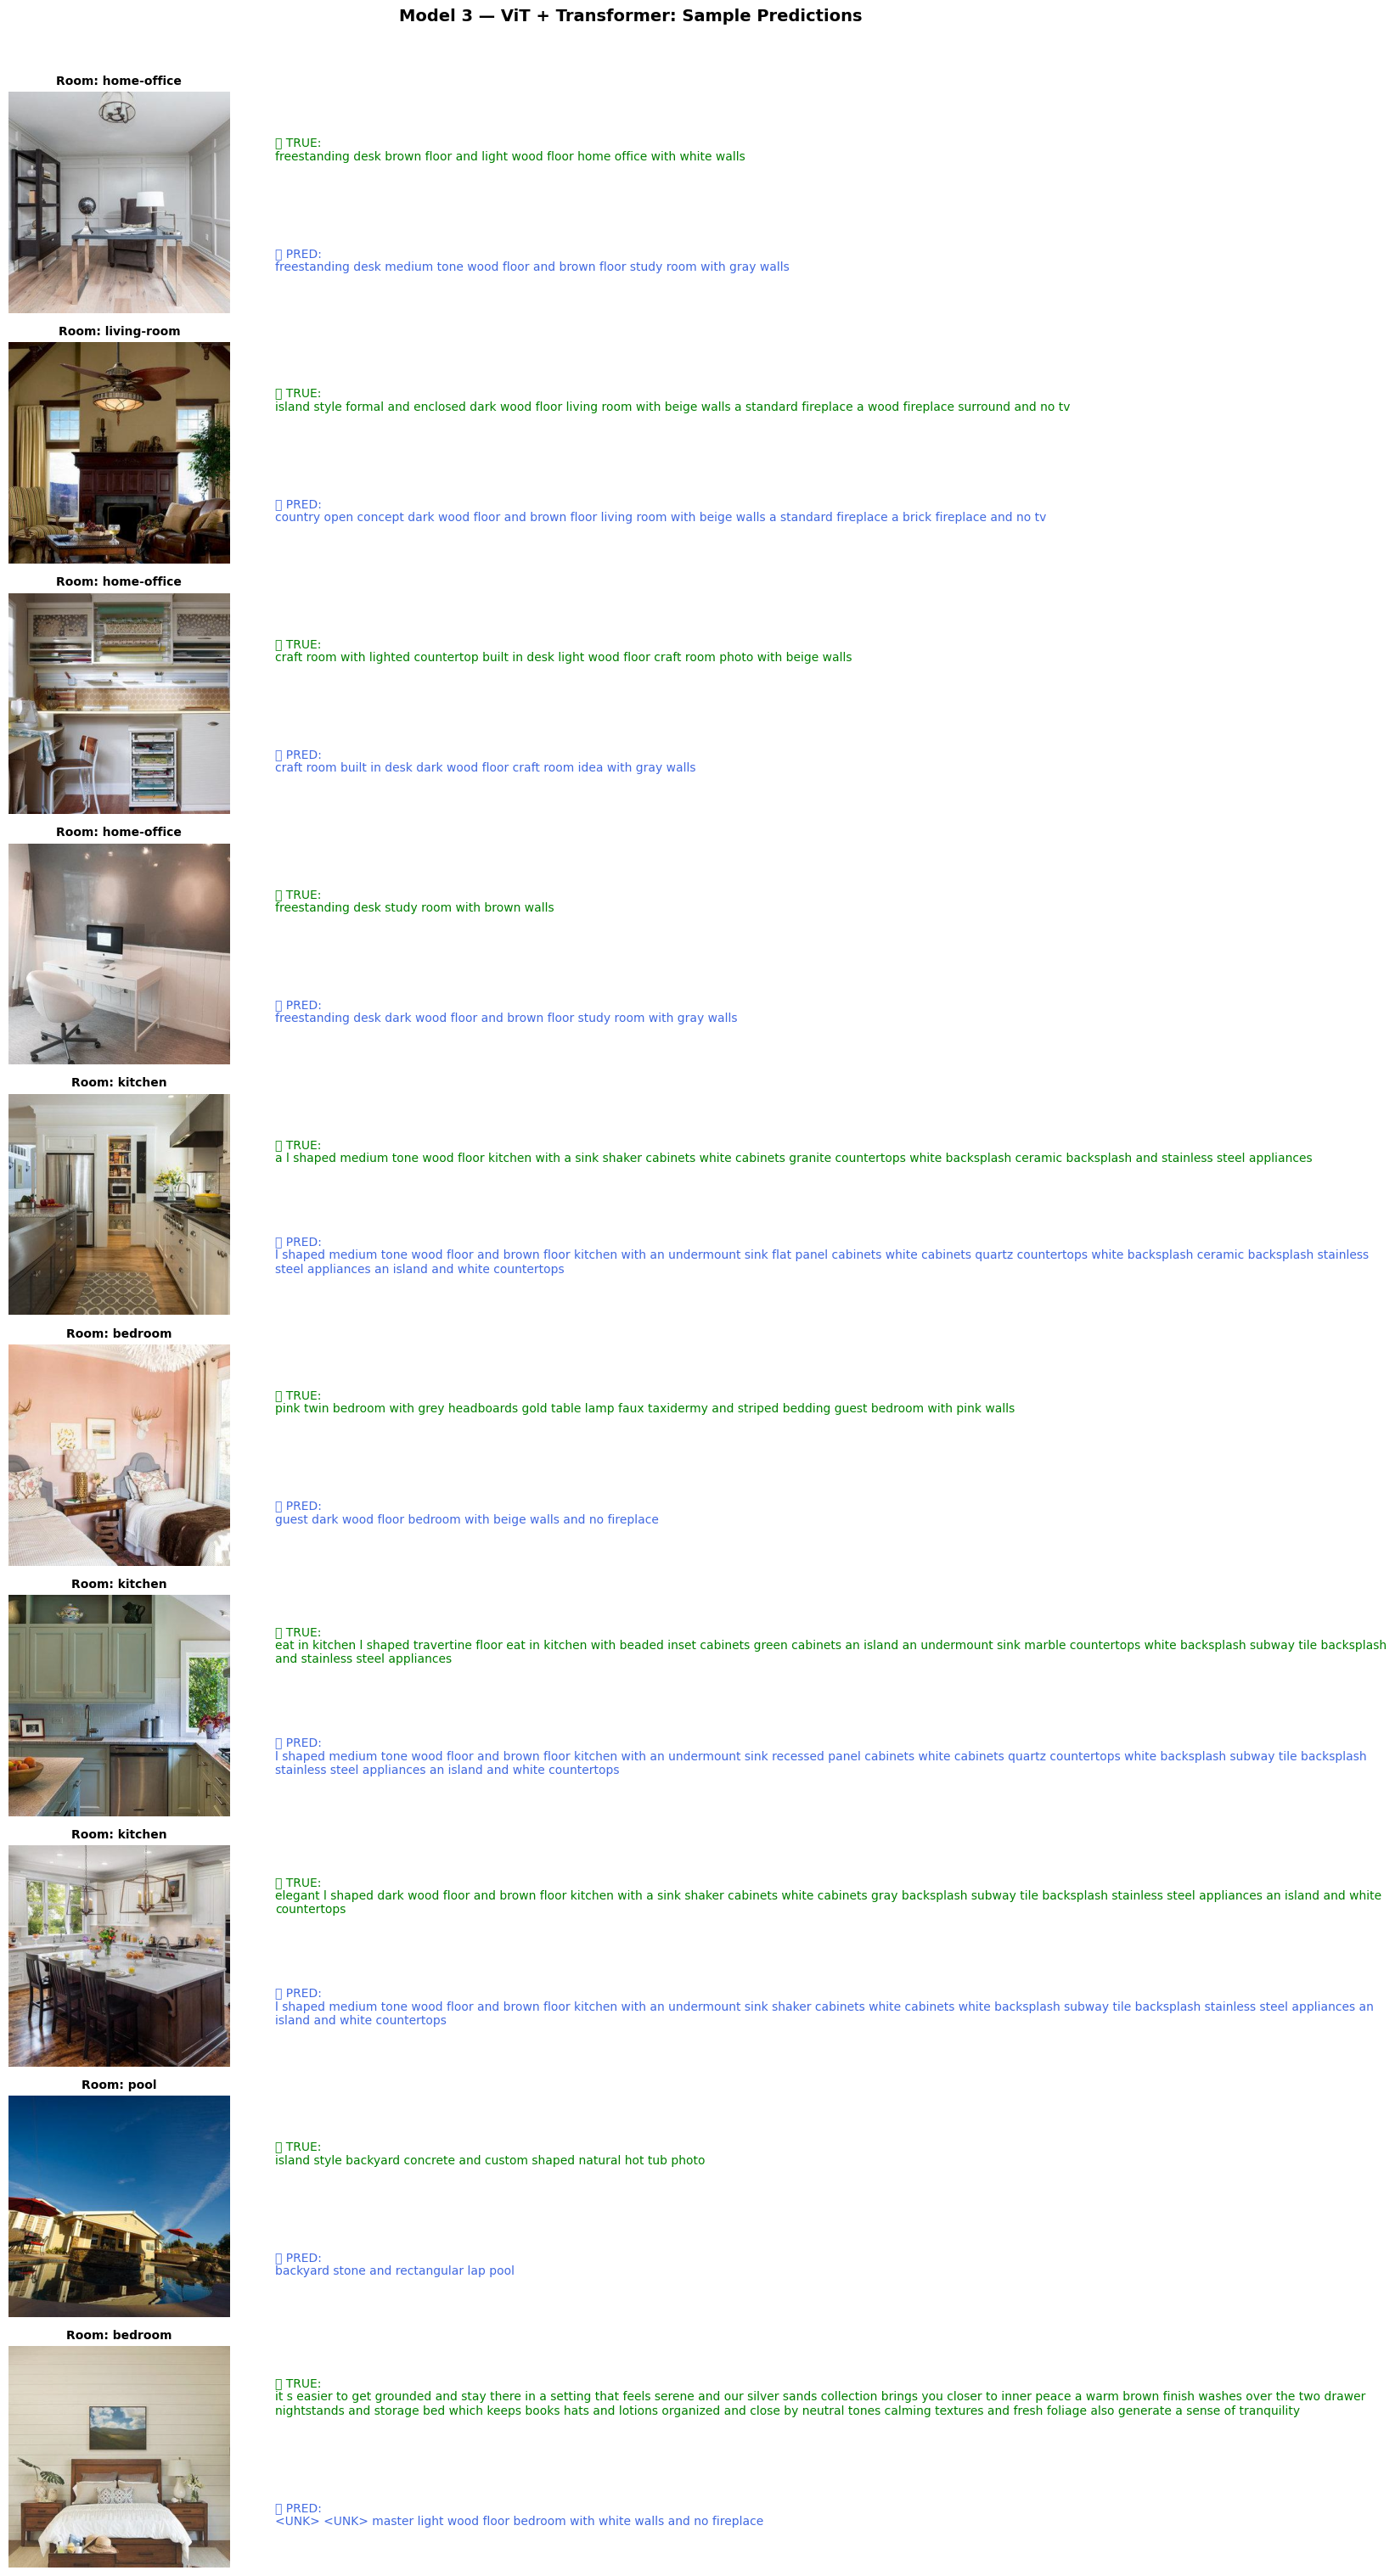

In [21]:
from IPython.display import display
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

def show_predictions(df, predictions, n=6):
    fig = plt.figure(figsize=(18, n*3))
    gs  = gridspec.GridSpec(n, 2, width_ratios=[1, 2])

    for i in range(n):
        row      = df.iloc[i]
        img_name = '/'.join(row['local_path'].split('/')[1:])
        image    = Image.open(IMAGES_BASE / img_name).convert('RGB')
        true_cap = references_raw[i]
        pred_cap = predictions[i]

        ax_img = fig.add_subplot(gs[i, 0])
        ax_img.imshow(image)
        ax_img.axis('off')
        ax_img.set_title(f"Room: {row['room_type']}", fontsize=10, fontweight='bold')

        ax_txt = fig.add_subplot(gs[i, 1])
        ax_txt.axis('off')
        ax_txt.text(0, 0.7, f"✅ TRUE:\n{true_cap}",
                    fontsize=10, color='green', wrap=True,
                    transform=ax_txt.transAxes)
        ax_txt.text(0, 0.2, f"🤖 PRED:\n{pred_cap}",
                    fontsize=10, color='royalblue', wrap=True,
                    transform=ax_txt.transAxes)

    plt.suptitle('Model 3 — ViT + Transformer: Sample Predictions',
                 fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(SAVE / 'model3_sample_predictions.png', bbox_inches='tight', dpi=150)
    plt.show()

show_predictions(test_df, predictions, n=10)